# Spike-triggered demo

Demonstration of spike-triggered epochs and averages using `SpikeData` and xarray signals.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DIR_PACKAGE = Path.cwd().parent
DIR_REPO = DIR_PACKAGE.parent
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))

from sim_data_analyzer.spike_data import SpikeData
from sim_data_analyzer.xr_diff import calc_xr_csd
from sim_data_analyzer.xr_io import load_xr
from sim_data_analyzer.xr_signal import filter_xr_signal, interp_time_outliers
from sim_data_analyzer.xr_spike_triggered import calc_xr_sta


In [2]:
# Parameters
TRIGGER_POP = 'ITS4'
RATE_SIGNAL_POP = 'IT3'
T_LIMITS = (5.0, 30.0)
#TIME_WIN = (-0.1, 0.1)   # seconds around each spike
#LFP_Y = 600.0
#CSD_Y = 600.0

FPATH_SIM_RESULT = (
    DIR_PACKAGE / 'dev_scratch' / 'data_src' / 'a1_lfp_30s' / 'data_00000_seed_1000.pkl'
)
DIRPATH_PROC = DIR_PACKAGE / 'dev_scratch' / 'data_proc' / 'a1_lfp_30s_0'
FPATH_LFP = DIRPATH_PROC / 'a1_lfp_30s_0_lfp.nc'
FPATH_RATES = DIRPATH_PROC / 'a1_lfp_30s_0_rates_dt_0.001.nc'
DIRPATH_OUT = DIRPATH_PROC / 'spike_triggered_demo'
#FPATH_SPIKES = DIRPATH_OUT / f'spikes_{TRIGGER_POP.lower()}_combined_abs_s.npz'
FPATH_SPIKES = DIRPATH_PROC / 'spike_data_demo/spikes_combined_ms.npz'

DIRPATH_OUT.mkdir(parents=True, exist_ok=True)
FPATH_SPIKES


PosixPath('/home/nnovikov/repo/sim_data_analyzer/dev_scratch/data_proc/a1_lfp_30s_0/spike_data_demo/spikes_combined_ms.npz')

In [3]:
# Load or extract combined trigger spikes in absolute seconds
if FPATH_SPIKES.exists():
    trigger_spikes = SpikeData.load(FPATH_SPIKES)
else:
    raise RuntimeError(f'Spike data file not found: {FPATH_SPIKES}')
    with FPATH_SIM_RESULT.open('rb') as fobj:
        sim_result = pickle.load(fobj)
    trigger_spikes = SpikeData.from_sim_result(
        sim_result,
        pop_names=[TRIGGER_POP],
        combine=True,
        t0=T_LIMITS[0],
        tmax=T_LIMITS[1],
        subtract_t0=False,
        ms=False,
        ndigits=6,
    )
    trigger_spikes.save(FPATH_SPIKES)

print(trigger_spikes.metadata)
print('Number of trigger spikes:', len(trigger_spikes.get_pop_spikes(TRIGGER_POP)[0]))
print('First trigger times:', trigger_spikes.get_pop_spikes(TRIGGER_POP)[0][:10])


{'combine': True, 't0': 5.0, 'tmax': 30.0, 'subtract_t0': False, 'ms': True, 'ndigits': 3}
Number of trigger spikes: 42253
First trigger times: [5001.05 5001.2  5001.95 5005.15 5005.4  5005.75 5005.8  5007.45 5008.25
 5008.35]


#### Spike-triggered LFP

In [4]:
# Load cached LFP
lfp = load_xr(FPATH_LFP, load=True)
lfp = interp_time_outliers(lfp).sel(time=slice(*T_LIMITS))
print(lfp)

<xarray.DataArray (y: 30, time: 50000)> Size: 12MB
array([[2.36930537, 2.39134454, 2.39122609, ..., 2.38109367, 2.39779311,
        2.38974136],
       [2.21548514, 2.20941802, 2.19723664, ..., 2.20255975, 2.21263184,
        2.19556531],
       [2.12651862, 2.13373879, 2.1028097 , ..., 2.12081966, 2.11671344,
        2.09520835],
       ...,
       [3.91887631, 3.91895235, 3.91911174, ..., 3.92054156, 3.91942727,
        3.91917549],
       [2.52459316, 2.52461368, 2.52474616, ..., 2.52553034, 2.52487875,
        2.52476894],
       [1.68735623, 1.68734728, 1.68747801, ..., 1.68787699, 1.68742372,
        1.68742169]], shape=(30, 50000))
Coordinates:
  * y        (y) int64 240B 0 100 200 300 400 500 ... 2500 2600 2700 2800 2900
  * time     (time) float64 400kB 5.0 5.0 5.001 5.002 ... 30.0 30.0 30.0 30.0
Attributes:
    outlier_interp:  {'name': 'interp_time_outliers', 'params': {'time_dim': ...


In [5]:
USE_CSD = 1

if USE_CSD:
    sig = calc_xr_csd(lfp)
    sig_name = 'CSD'
else:
    sig = lfp
    sig_name = 'LFP'

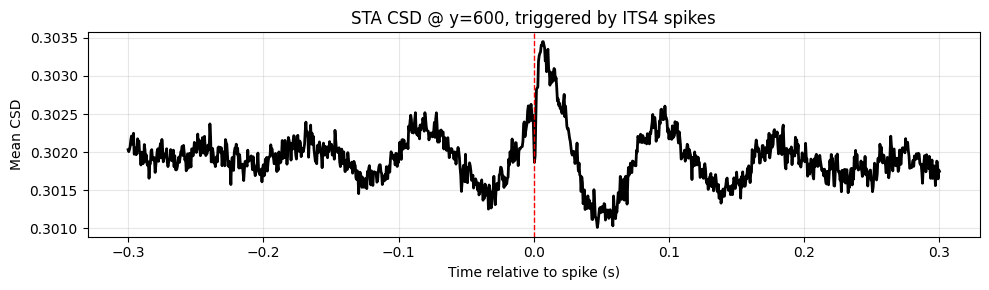

In [45]:
TIME_WIN = (-0.3, 0.3)

SIG_Y = 600
TRIGGER_POP = 'ITS4'

# Spike-triggered LFP for one depth channel
sig_ = sig.sel(y=SIG_Y)
lfp_sta = calc_xr_sta(
    sig_,
    trigger_spikes,
    TIME_WIN,
    pop_name=TRIGGER_POP,
    time_units='s',
    return_mode='both',
)

X_epochs = lfp_sta['epochs']
X_avg = lfp_sta['avg']

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(X_avg.time_rel, X_avg.values, color='k', linewidth=2)
ax.axvline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Time relative to spike (s)')
ax.set_ylabel(f'Mean {sig_name}')
ax.set_title(f'STA {sig_name} @ y={SIG_Y:g}, triggered by {TRIGGER_POP} spikes')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

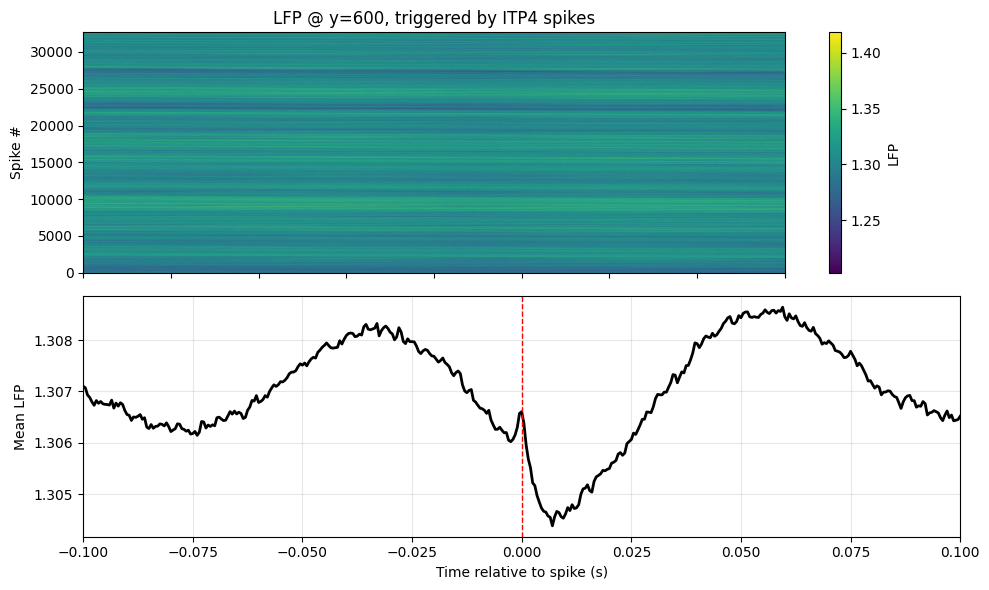

In [ ]:
# Plot spike-triggered LFP epochs and average
X_epochs = lfp_sta['epochs']
X_avg = lfp_sta['avg']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
im = ax1.imshow(
    X_epochs.values,
    aspect='auto',
    origin='lower',
    extent=[X_epochs.time_rel.values[0], X_epochs.time_rel.values[-1], 0, X_epochs.sizes['spike']],
    cmap='viridis',
)
fig.colorbar(im, ax=ax1, label='LFP')
ax1.set_ylabel('Spike #')
ax1.set_title(f'LFP @ y={LFP_Y:g}, triggered by {TRIGGER_POP} spikes')

ax2.plot(X_avg.time_rel, X_avg.values, color='k', linewidth=2)
ax2.axvline(0, color='r', linestyle='--', linewidth=1)
ax2.set_xlabel('Time relative to spike (s)')
ax2.set_ylabel('Mean LFP')
ax2.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
# Spike-triggered CSD for one depth channel
csd = calc_xr_csd(lfp)
csd_signal = csd.sel(y=CSD_Y)
csd_sta = calc_xr_sta(
    csd_signal,
    trigger_spikes,
    TIME_WIN,
    pop_name=TRIGGER_POP,
    time_units='s',
    return_mode='both',
)

print(csd_sta['epochs'])
print(csd_sta['avg'])


<xarray.DataArray (spike: 32662, time_rel: 401)>
array([[0.28748165, 0.29171498, 0.2930783 , ..., 0.31076054, 0.30343923,
        0.29892881],
       [0.28748165, 0.29171498, 0.2930783 , ..., 0.31076054, 0.30343923,
        0.29892881],
       [0.30793832, 0.30880896, 0.26034021, ..., 0.30236826, 0.31398993,
        0.30547881],
       ...,
       [0.31251517, 0.28972762, 0.29875587, ..., 0.28613038, 0.29099385,
        0.27580784],
       [0.28972762, 0.29875587, 0.32859343, ..., 0.29099385, 0.27580784,
        0.27985413],
       [0.32859343, 0.32782502, 0.34756204, ..., 0.27985413, 0.31431979,
        0.321321  ]])
Coordinates:
  * spike     (spike) int32 0 1 2 3 4 5 ... 32656 32657 32658 32659 32660 32661
  * time_rel  (time_rel) float64 -0.1 -0.0995 -0.099 ... 0.099 0.0995 0.1
Attributes:
    outlier_interp:  {'name': 'interp_time_outliers', 'params': {'time_dim': ...
<xarray.DataArray (time_rel: 401)>
array([0.30202434, 0.30197471, 0.30230493, 0.30215846, 0.30217904,
       0.302

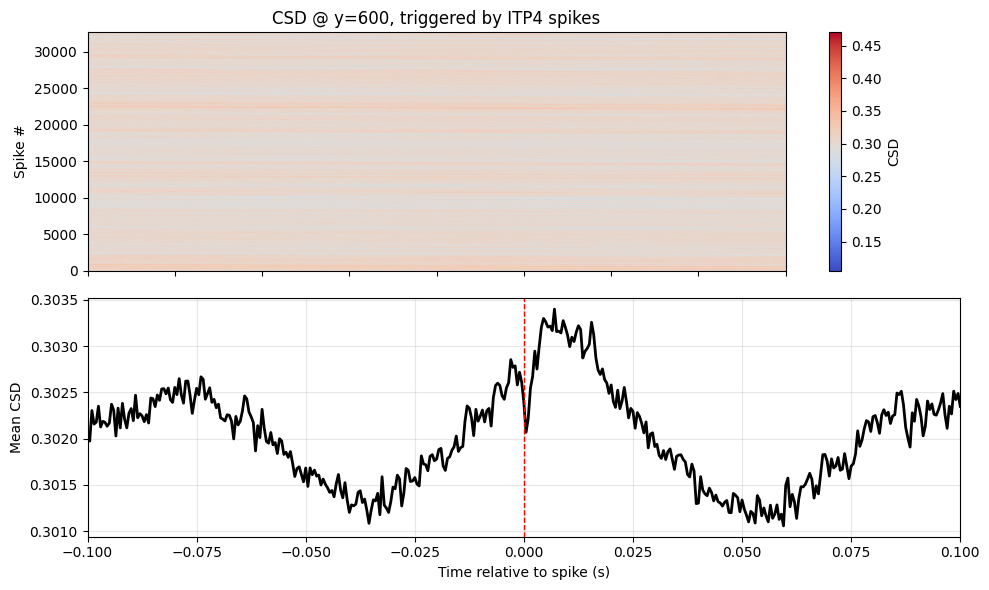

In [ ]:
# Plot spike-triggered CSD epochs and average
X_epochs = csd_sta['epochs']
X_avg = csd_sta['avg']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
im = ax1.imshow(
    X_epochs.values,
    aspect='auto',
    origin='lower',
    extent=[X_epochs.time_rel.values[0], X_epochs.time_rel.values[-1], 0, X_epochs.sizes['spike']],
    cmap='coolwarm',
)
fig.colorbar(im, ax=ax1, label='CSD')
ax1.set_ylabel('Spike #')
ax1.set_title(f'CSD @ y={CSD_Y:g}, triggered by {TRIGGER_POP} spikes')

ax2.plot(X_avg.time_rel, X_avg.values, color='k', linewidth=2)
ax2.axvline(0, color='r', linestyle='--', linewidth=1)
ax2.set_xlabel('Time relative to spike (s)')
ax2.set_ylabel('Mean CSD')
ax2.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


#### Spike-triggered rates

In [23]:
FILT_TYPE = 'bandpass'
FILT_FREQ = (2, 200)

#FILT_TYPE = 'lowpass'
#FILT_FREQ = 30

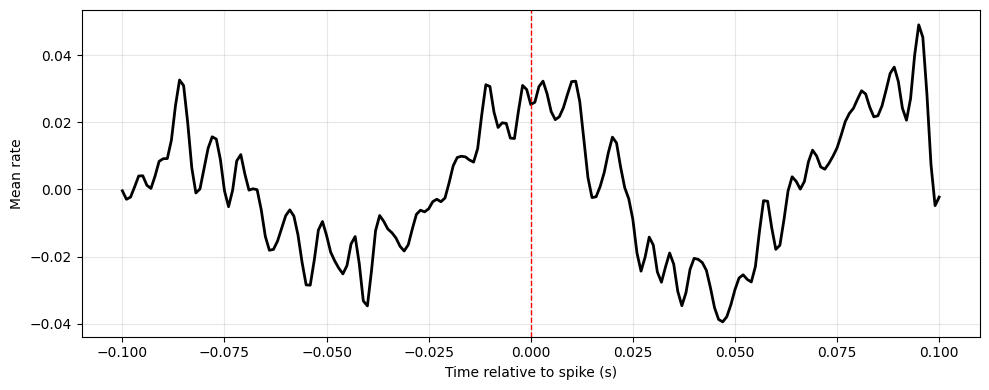

In [24]:
# Load cached firing rates
rates = load_xr(FPATH_RATES, load=True)
rates = rates.sel(time=slice(*T_LIMITS))
rates = filter_xr_signal(rates, fband=FILT_FREQ, btype=FILT_TYPE)
#print(rates)

# Spike-triggered firing-rate signal for one population
rate_signal = rates.sel(pop=RATE_SIGNAL_POP)
rate_sta = calc_xr_sta(
    rate_signal,
    trigger_spikes,
    TIME_WIN,
    pop_name=TRIGGER_POP,
    time_units='s',
    return_mode='both',
)

# Plot spike-triggered firing-rate epochs and average
X_epochs = rate_sta['epochs']
X_avg = rate_sta['avg']

fig, ax2 = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
ax2.plot(X_avg.time_rel, X_avg.values, color='k', linewidth=2)
ax2.axvline(0, color='r', linestyle='--', linewidth=1)
ax2.set_xlabel('Time relative to spike (s)')
ax2.set_ylabel('Mean rate')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
